In [18]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
from matplotlib.colors import TwoSlopeNorm
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize

In [19]:
# load and view data
ds = xr.open_dataset('xboutput.nc')
ds

<xarray.Dataset> Size: 16GB
Dimensions:      (globaltime: 1801, ny: 501, nx: 198)
Coordinates:
  * globaltime   (globaltime) float64 14kB 0.0 2.0 4.0 ... 3.598e+03 3.6e+03
    globalx      (ny, nx) float64 794kB ...
    globaly      (ny, nx) float64 794kB ...
Dimensions without coordinates: ny, nx
Data variables:
    _parameters  float64 8B ...
    zs           (globaltime, ny, nx) float64 1GB ...
    zb           (globaltime, ny, nx) float64 1GB ...
    H            (globaltime, ny, nx) float64 1GB ...
    Fx           (globaltime, ny, nx) float64 1GB ...
    Fy           (globaltime, ny, nx) float64 1GB ...
    ve           (globaltime, ny, nx) float64 1GB ...
    Svtot        (globaltime, ny, nx) float64 1GB ...
    Sutot        (globaltime, ny, nx) float64 1GB ...
    ve_sed       (globaltime, ny, nx) float64 1GB ...
    dzsdx        (globaltime, ny, nx) float64 1GB ...
    dzsdy        (globaltime, ny, nx) float64 1GB ...
Attributes:
    Conventions:     CF-1.4
    Producer:        XBeach littoral zone wave model (http://www.xbeach.org)
    Build-Revision:  
    Build-Date:      Mon Mar  2 01:09:57 PM EST 2026
    URL:

Animation saved as wave_animation.gif


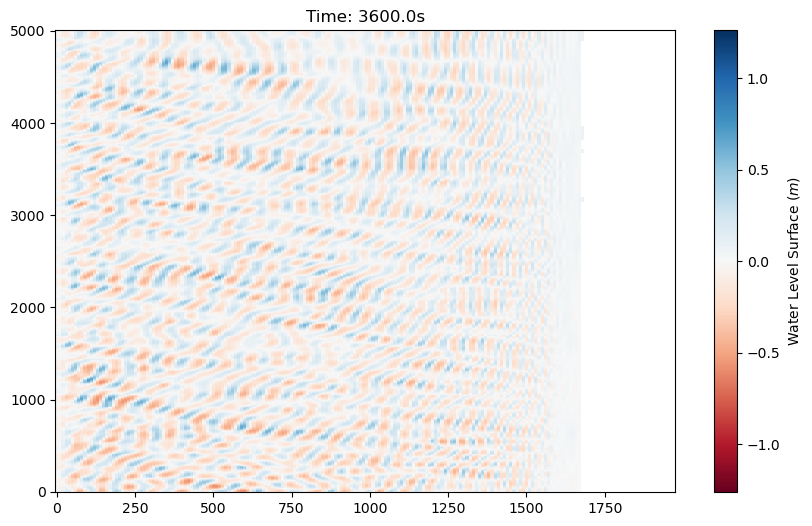

In [20]:
# 2d animation
x = ds['globalx']
y = ds['globaly']
time = ds['globaltime']

fig, ax = plt.subplots(figsize=(10, 6))

# vmin = float(ds['zs'].min())
vmin = -float(ds['zs'].max())
vmax = float(ds['zs'].max())
norm = TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax)

quad = ax.pcolormesh(ds.globalx, ds.globaly, ds['zs'].isel(globaltime=0), norm=norm, cmap='RdBu', shading='auto')

fig.colorbar(quad, label='Water Level Surface ($m$)')
ax.set_title('Wave Field (Red=Trough, Blue=Crest)')

def update(frame):
    quad.set_array(ds['zs'].isel(globaltime=frame).values.ravel())
    ax.set_title(f"Time: {ds.globaltime[frame].values:.1f}s")
    return quad,

ani = animation.FuncAnimation(fig, update, frames=len(ds.globaltime), blit=True)
ani.save('wave_animation.gif', writer='pillow', fps=10)
print("Animation saved as wave_animation.gif")

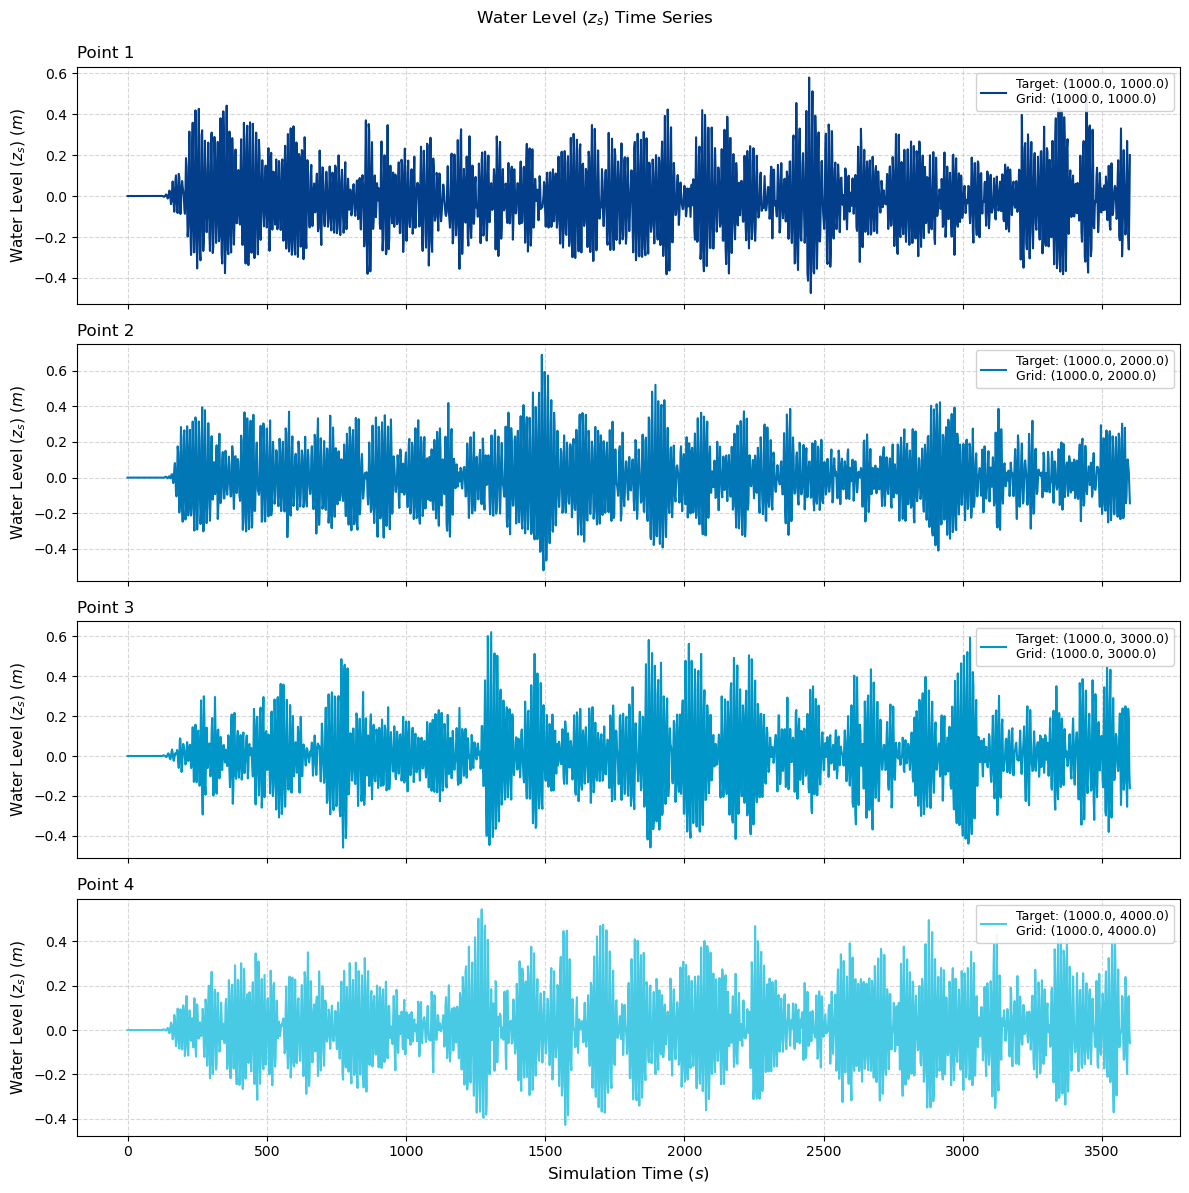

In [36]:
target_points = [
    (1000.0, 1000.0),   
    (1000.0, 2000.0),   
    (1000.0, 3000.0),  
    (1000.0, 4000.0)   
]

X_grid = ds['globalx'].values
Y_grid = ds['globaly'].values
time = ds['globaltime'].values

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

colors = ['#023e8a', '#0277b6', '#0096c7', '#48cae4']

for idx, (target_x, target_y) in enumerate(target_points):
    
    distance = (X_grid - target_x)**2 + (Y_grid - target_y)**2
    
    ny_idx, nx_idx = np.unravel_index(np.argmin(distance), distance.shape)
    
    actual_x = X_grid[ny_idx, nx_idx]
    actual_y = Y_grid[ny_idx, nx_idx]
    
    zs_series = ds['zs'].isel(ny=ny_idx, nx=nx_idx).values
    
    ax = axes[idx]

    ax.plot(time, zs_series, color=colors[idx], linewidth=1.5,
            label=f"Target: ({target_x}, {target_y})\nGrid: ({actual_x:.1f}, {actual_y:.1f})")

    ax.set_title(f"Point {idx+1}", loc='left')
    ax.set_ylabel('Water Level ($z_s$) ($m$)', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', fontsize=9, framealpha=0.9)

axes[-1].set_xlabel('Simulation Time ($s$)', fontsize=12)
fig.suptitle('Water Level ($z_s$) Time Series', y=0.99)

plt.tight_layout()
plt.show()

3D Animation saved as wave_3d_final.gif


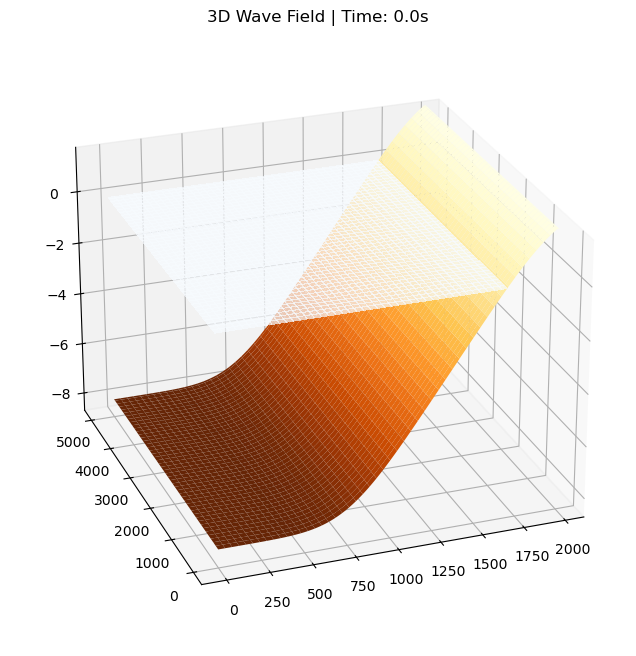

In [22]:
# 3d animation
X = ds['globalx'].isel(ny=0).values  # slice along the ny dimension
Y = ds['globaly'].isel(nx=0).values  # slice along the nx dimension
X_mesh, Y_mesh = np.meshgrid(X, Y)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

bed = ds['zb'].isel(globaltime=0).values

def update(frame):
    ax.clear()
    surface_deviation = ds['zs'].isel(globaltime=frame).values
    ax.plot_surface(X_mesh, Y_mesh, bed, cmap='YlOrBr_r', linewidth=0, antialiased=True)
    surf = ax.plot_surface(X_mesh, Y_mesh, surface_deviation, cmap='Blues', linewidth=0, antialiased=False, alpha=0.7)
    ax.set_zlim(np.min(bed)-0.5, 1.5)
    ax.set_title(f"3D Wave Field | Time: {ds.globaltime[frame].values:.1f}s")
    ax.view_init(elev=25, azim=-110)
    return surf,

ani = animation.FuncAnimation(fig, update, frames=len(ds.globaltime), blit=False)
ani.save('wave_3d_final.gif', writer='pillow', fps=6)
print("3D Animation saved as wave_3d_final.gif")

Sediment vector animation saved as sediment_vectors.gif


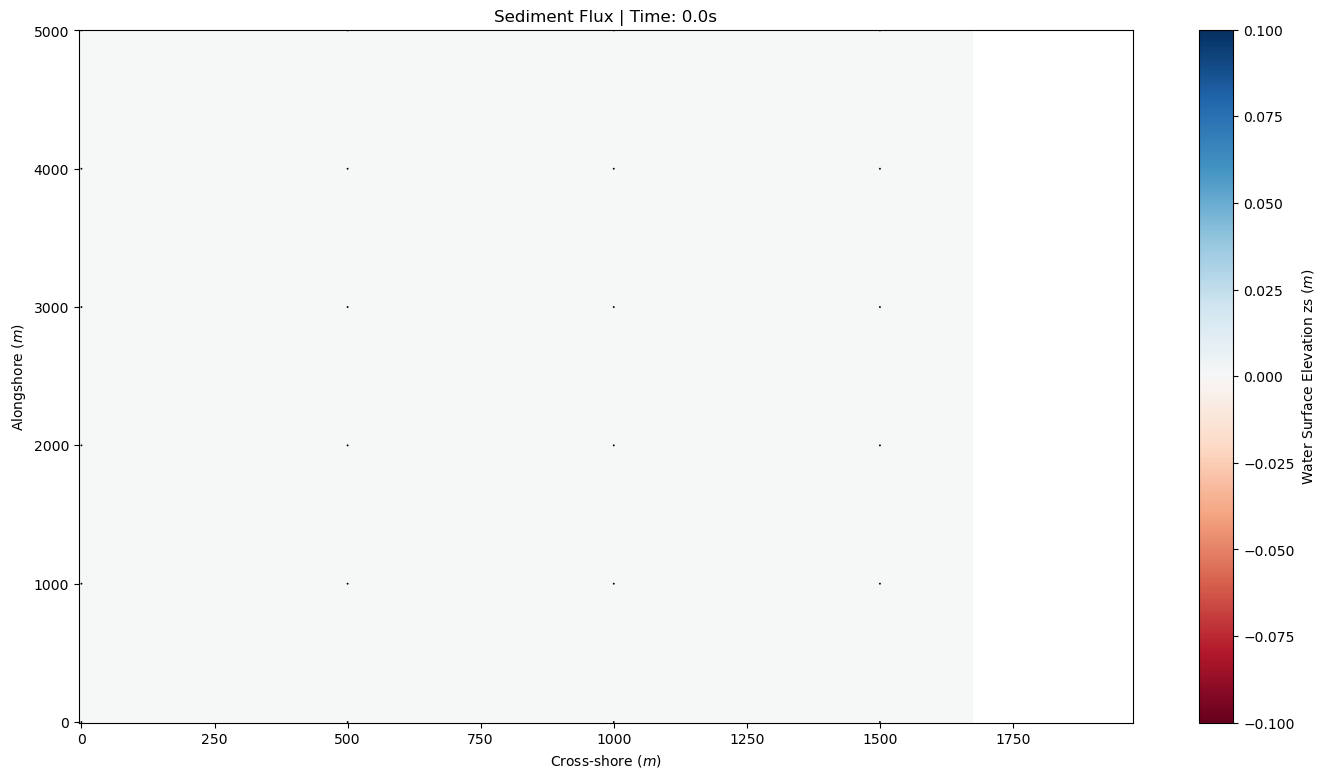

In [25]:
# plot sediment flux vector field
fig, ax = plt.subplots(figsize=(17, 9))

# Using zs (Water Surface Elevation) for the background
background = ds['zs'].isel(globaltime=0)
im = ax.pcolormesh(X_mesh, Y_mesh, background, cmap='RdBu', shading='auto')
fig.colorbar(im, label='Water Surface Elevation zs ($m$)')

skip = (slice(None, None, 100), slice(None, None, 50)) 

# FIX: Sum across the sediment_classes dimension to get total suspended flux
u_full = ds['Sutot'].isel(globaltime=-1).values
v_full = ds['Svtot'].isel(globaltime=-1).values

X_plot = X_mesh[skip]
Y_plot = Y_mesh[skip]
u_plot = u_full[skip]
v_plot = v_full[skip]

Q = ax.quiver(X_plot, Y_plot, u_plot, v_plot, color='k', scale=1, width=0.002)

ax.set_title('Sediment Flux')
ax.set_xlabel('Cross-shore ($m$)')
ax.set_ylabel('Alongshore ($m$)')

def update(frame):
    # Flatten the background array for the current frame
    im.set_array(ds['zs'].isel(globaltime=frame).values.ravel())
    
    # FIX: Sum across sediment classes for the current animation frame
    u = ds['Sutot'].isel(globaltime=frame).values[skip]
    v = ds['Svtot'].isel(globaltime=frame).values[skip]
    
    Q.set_UVC(u, v)
    
    ax.set_title(f"Sediment Flux | Time: {ds.globaltime[frame].values:.1f}s")
    return im, Q

ani = animation.FuncAnimation(fig, update, frames=len(ds.globaltime), blit=False)
ani.save('sediment_vectors.gif', writer='pillow', fps=8)
print("Sediment vector animation saved as sediment_vectors.gif")

Done calculating components! Finding magnitude...


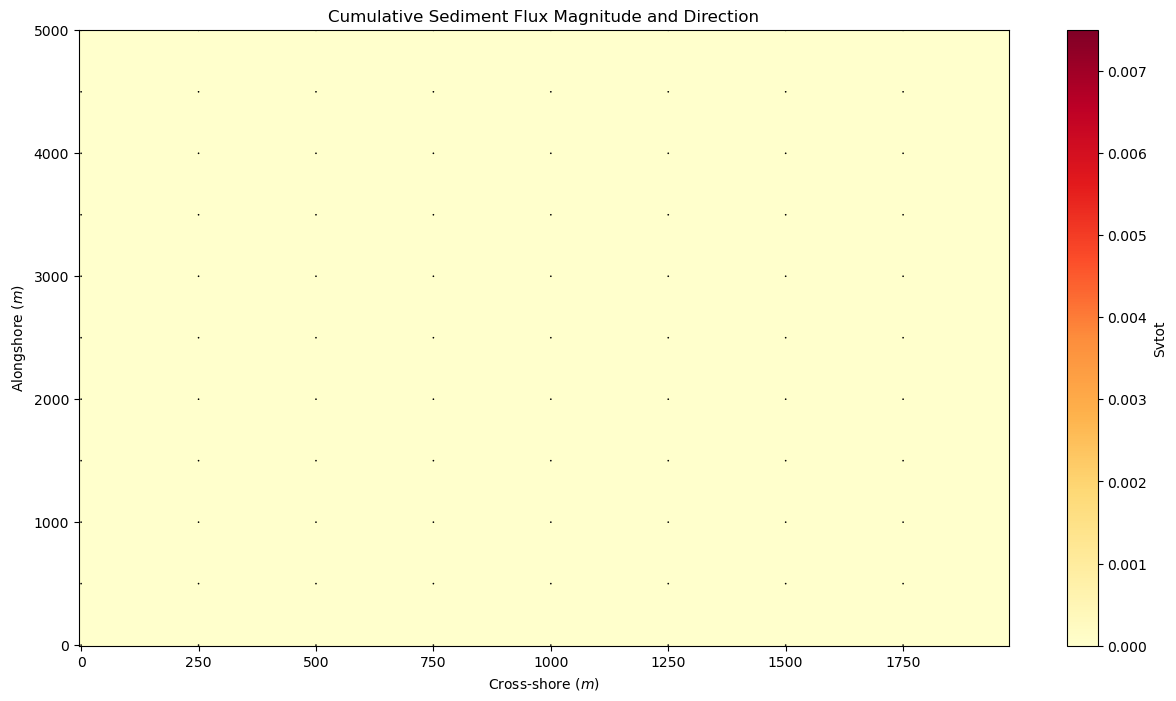

In [28]:
X = ds['globalx'].isel(ny=0).values  
Y = ds['globaly'].isel(nx=0).values  
X_mesh, Y_mesh = np.meshgrid(X, Y)

time = ds['globaltime'].values
dt = np.diff(time) 
dt = np.append(dt, dt[-1]) 

ny, nx = len(Y), len(X)
u_sum = np.zeros((ny, nx))
v_sum = np.zeros((ny, nx))

for i in range(len(time)):
    # Extract just this 2D timestep, sum sediment classes, and multiply by dt
    u_step = ds['Sutot'].isel(globaltime=i).values.squeeze() * dt[i]
    v_step = ds['Svtot'].isel(globaltime=i).values.squeeze() * dt[i]
    
    u_sum += u_step
    v_sum += v_step

print("Done calculating components! Finding magnitude...")

mag_sum = np.sqrt(u_sum**2 + v_sum**2)

fig, ax = plt.subplots(figsize=(15, 8))

im = ax.pcolormesh(X_mesh, Y_mesh, mag_sum, cmap='YlOrRd', vmin=0, vmax=.0075, shading='auto')
cbar = fig.colorbar(im, label='Svtot')

skip = (slice(None, None, 50), slice(None, None, 25))
Q = ax.quiver(X_mesh[skip], Y_mesh[skip], u_sum[skip], v_sum[skip], color='black', scale=2, width=0.002)

ax.set_title('Cumulative Sediment Flux Magnitude and Direction')
ax.set_xlabel('Cross-shore ($m$)')
ax.set_ylabel('Alongshore ($m$)')
plt.show()

Done calculating components! Finding magnitude...


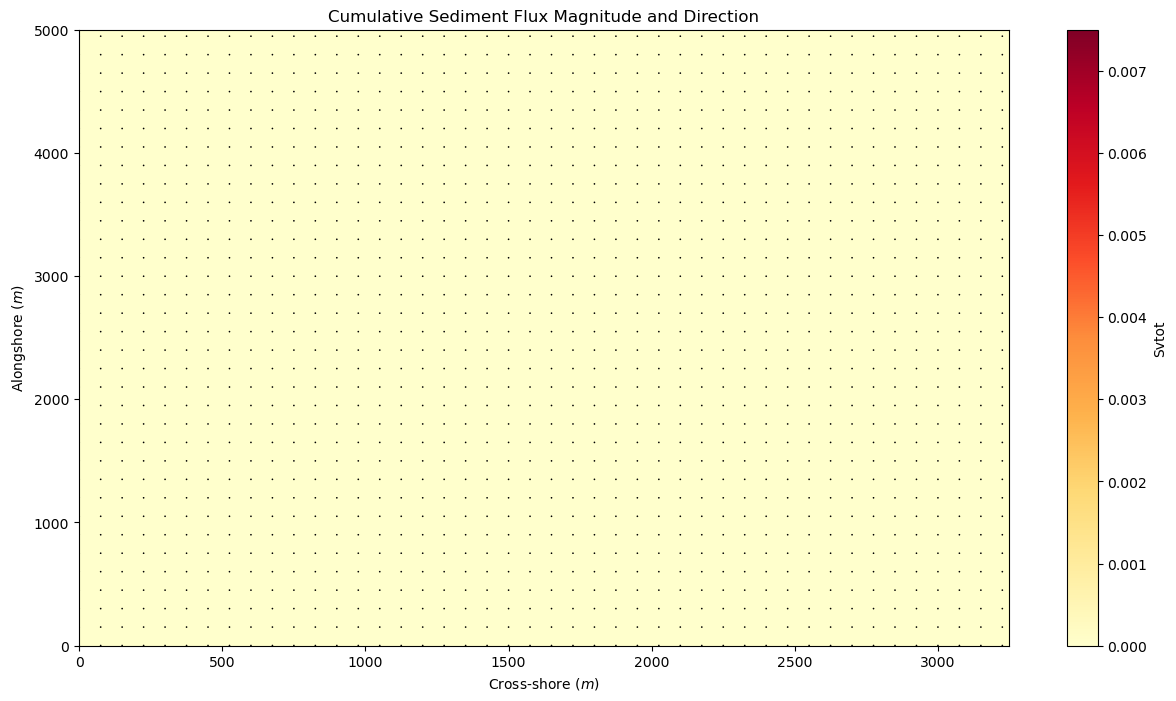

In [7]:
X = ds['globalx'].isel(ny=0).values  
Y = ds['globaly'].isel(nx=0).values  
X_mesh, Y_mesh = np.meshgrid(X, Y)

time = ds['globaltime'].values
dt = np.diff(time) 
dt = np.append(dt, dt[-1]) 

ny, nx = len(Y), len(X)
u_sum = np.zeros((ny, nx))
v_sum = np.zeros((ny, nx))

for i in range(len(time)):
    u_step = ds['Sutot'].isel(globaltime=i).values.squeeze() * dt[i]
    v_step = ds['Svtot'].isel(globaltime=i).values.squeeze() * dt[i]
    
    u_sum += u_step
    v_sum += v_step

print("Done calculating components! Finding magnitude...")

mag_sum = np.sqrt(u_sum**2 + v_sum**2)

fig, ax = plt.subplots(figsize=(15, 8))

im = ax.pcolormesh(X_mesh, Y_mesh, mag_sum, cmap='YlOrRd', vmin=0, vmax=.0075, shading='auto')
cbar = fig.colorbar(im, label='Svtot')

skip = (slice(None, None, 50), slice(None, None, 25))
Q = ax.quiver(X_mesh[skip], Y_mesh[skip], u_sum[skip], v_sum[skip], color='black', scale=2, width=0.002)

ax.set_title('Cumulative Sediment Flux Magnitude and Direction')
ax.set_xlabel('Cross-shore ($m$)')
ax.set_ylabel('Alongshore ($m$)')
plt.show()

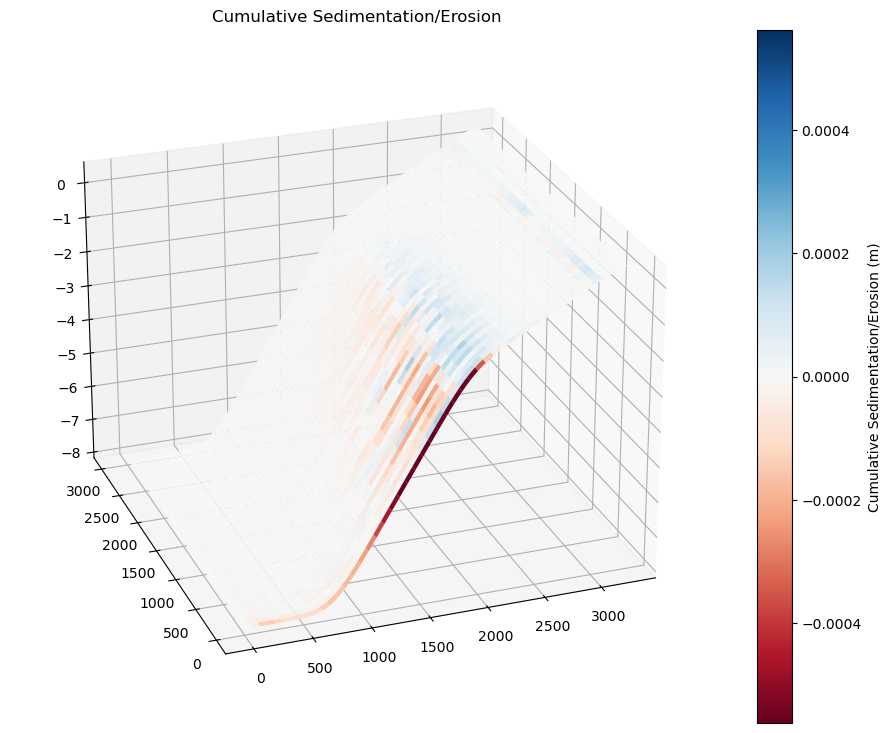

In [7]:
sedero = ds['sedero'].isel(globaltime=-1).values

limit = .5*max(abs(sedero.min()), abs(sedero.max()))
norm = Normalize(vmin=-limit, vmax=limit)

colors = cm.RdBu(norm(sedero))

fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X_mesh, Y_mesh, bed, facecolors=colors, linewidth=0, antialiased=True, shade=False)

m = cm.ScalarMappable(cmap=cm.RdBu, norm=norm)
m.set_array(sedero)
fig.colorbar(m, ax=ax, label='Cumulative Sedimentation/Erosion (m)')

ax.set_title('Cumulative Sedimentation/Erosion')
ax.view_init(elev=25, azim=-110)
plt.show()

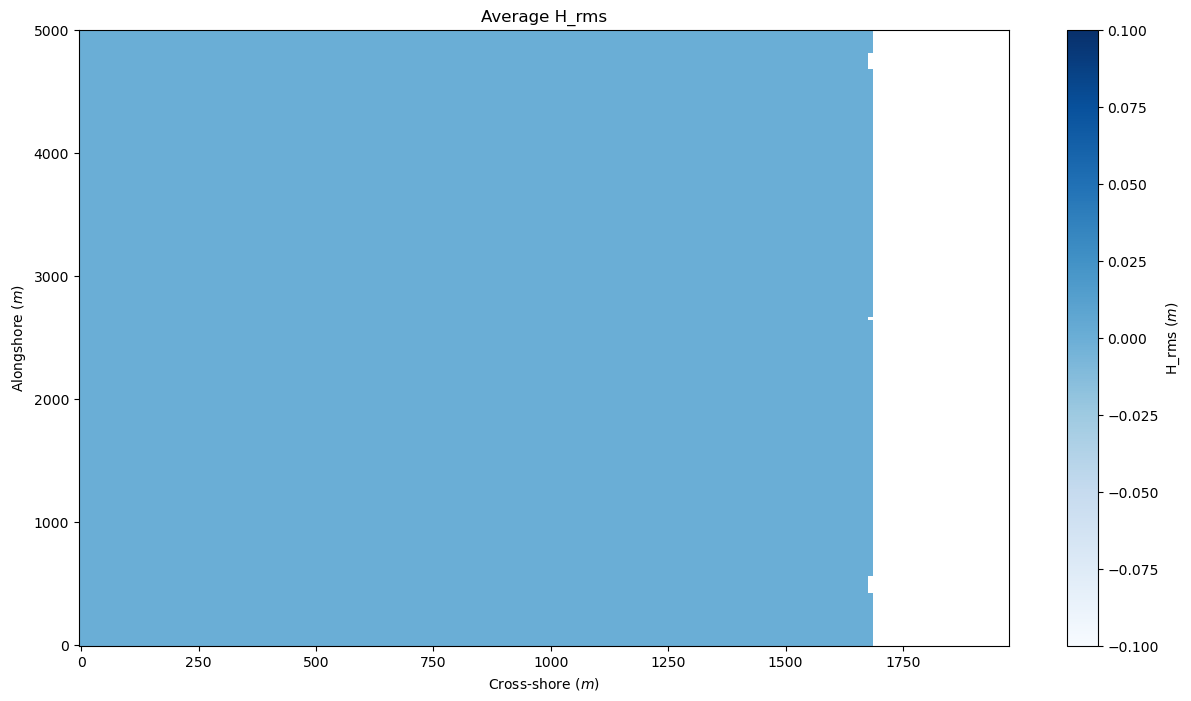

In [32]:
X = ds['globalx'].isel(ny=0).values  # slice along the ny dimension
Y = ds['globaly'].isel(nx=0).values  # slice along the nx dimension
X_mesh, Y_mesh = np.meshgrid(X, Y)

H_rms_mean = ds['H'].mean(dim='globaltime').values

fig, ax = plt.subplots(figsize=(15, 8))

im = ax.pcolormesh(X_mesh, Y_mesh, H_rms_mean, cmap='Blues', shading='auto')
cbar = fig.colorbar(im, label='H_rms ($m$)')

ax.set_title('Average H_rms')
ax.set_xlabel('Cross-shore ($m$)')
ax.set_ylabel('Alongshore ($m$)')
plt.show()

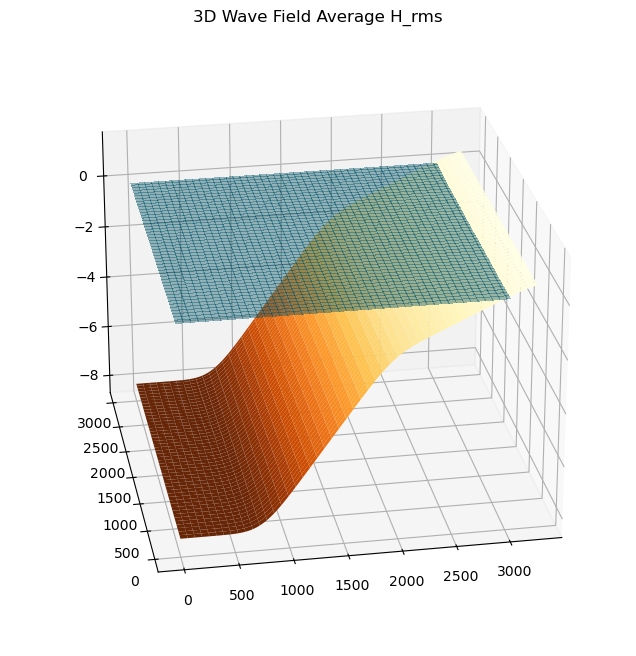

In [10]:
# 3d h_rms plot
X = ds['globalx'].isel(ny=0).values  # slice along the ny dimension
Y = ds['globaly'].isel(nx=0).values  # slice along the nx dimension
X_mesh, Y_mesh = np.meshgrid(X, Y)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

bed = ds['zb'].isel(globaltime=0).values
H_rms_mean = ds['H'].mean(dim='globaltime').values
ax.plot_surface(X_mesh, Y_mesh, bed, cmap='YlOrBr_r', linewidth=0, antialiased=True)
ax.plot_surface(X_mesh, Y_mesh, H_rms_mean, color='#006884',linewidth=0, antialiased=False, alpha=0.4)
ax.set_zlim(np.min(bed)-0.5, 1.5)
ax.set_title(f"3D Wave Field Average H_rms")
ax.view_init(elev=25, azim=-100)

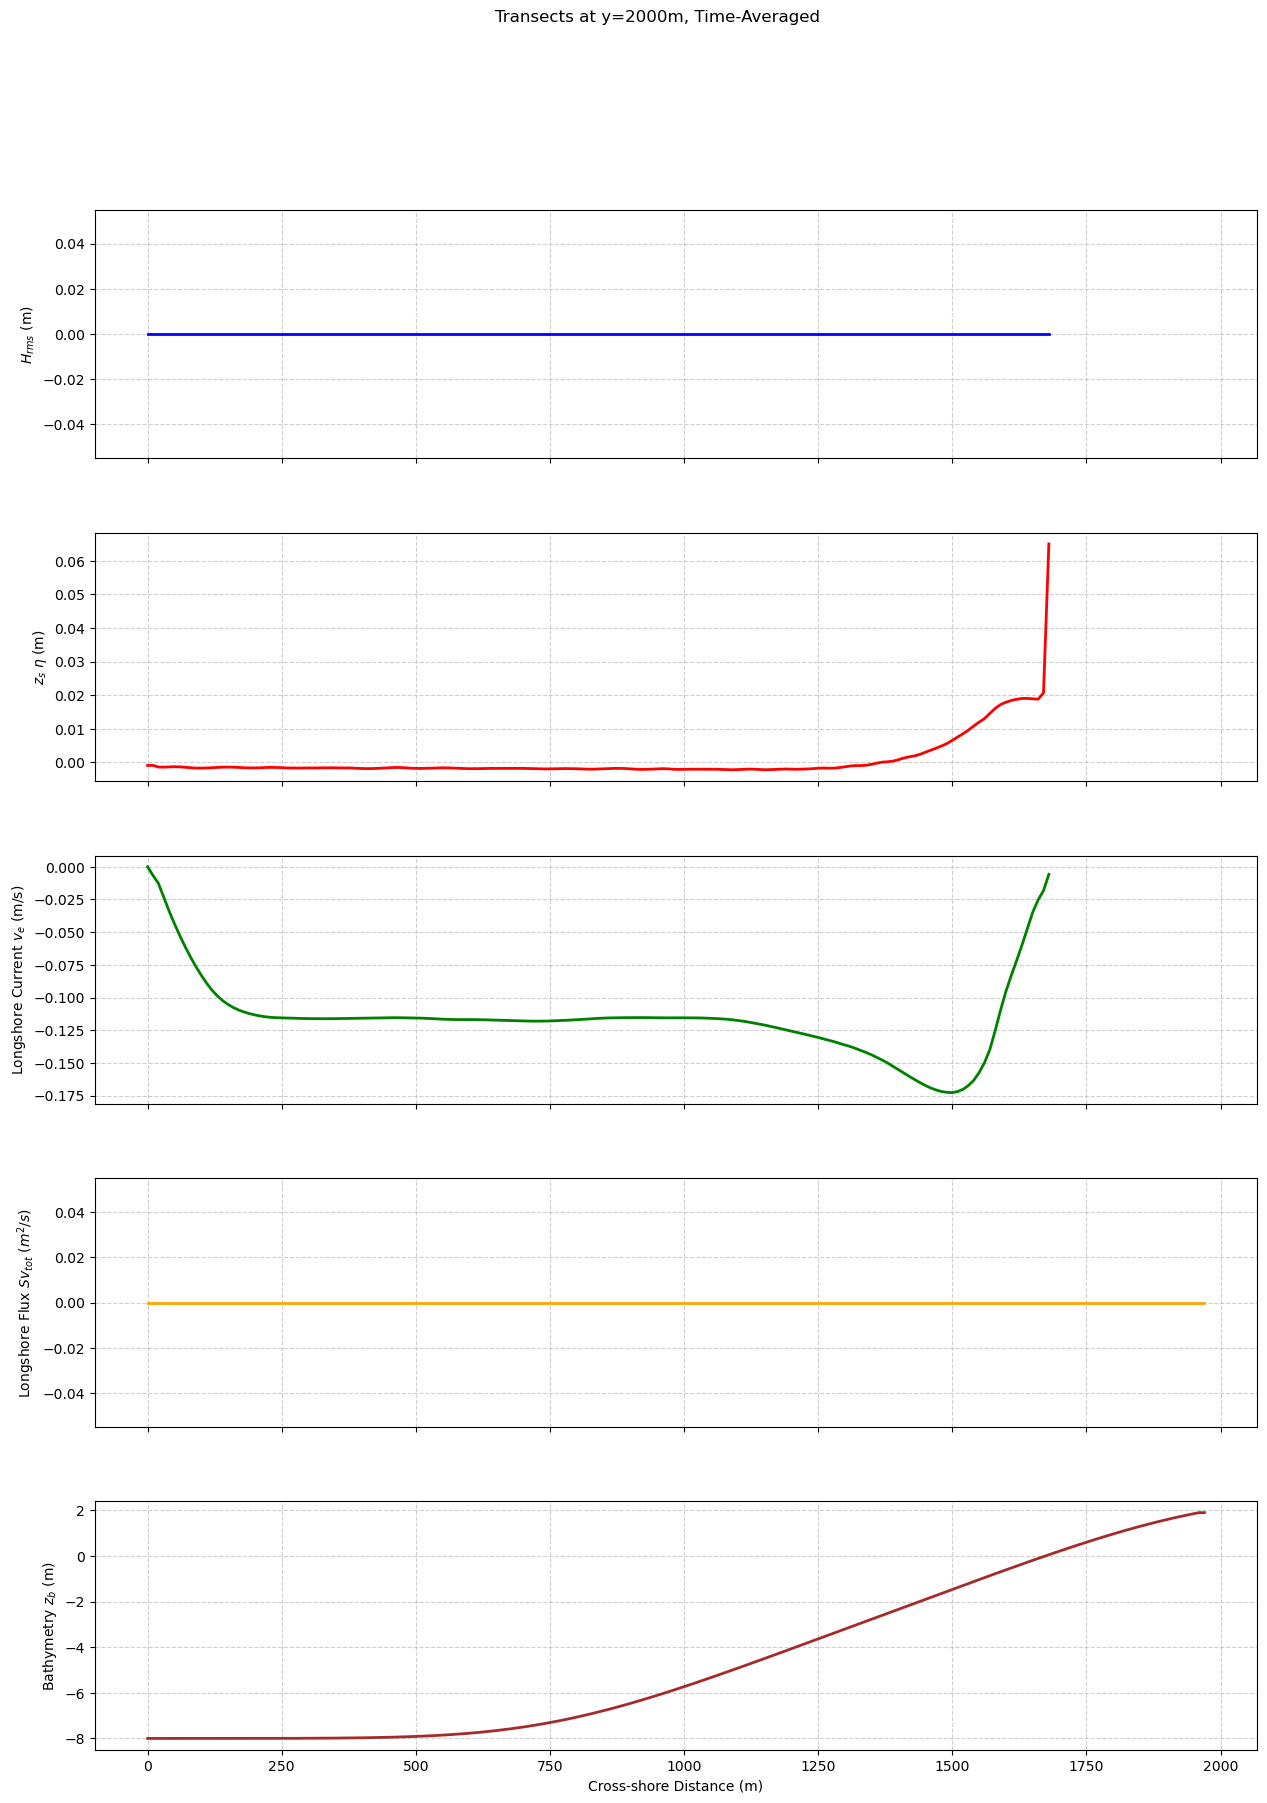

In [46]:
# change y transect value if model space was changed

y_coords = ds['globaly'].isel(nx=0).values
ny_idx = np.abs(y_coords - 2000).argmin()
actual_y = y_coords[ny_idx]
x_coords = ds['globalx'].isel(ny=ny_idx).values

vars_to_plot = [
    ('H', '$H_{rms}$ (m)', 'blue'),
    ('zs', '$z_s$ $\eta$ (m)', 'red'),
    ('ve', 'Longshore Current $v_e$ (m/s)', 'green'),
    ('Svtot', 'Longshore Flux $Sv_{tot}$ ($m^2/s$)', 'orange'),
    ('zb', 'Bathymetry $z_b$ (m)', 'brown')
]

n = len(vars_to_plot)

fig, axes = plt.subplots(n, 1, figsize=(15, 4*n), sharex=True)
plt.subplots_adjust(hspace=0.3)

for i, (var_name, label, color) in enumerate(vars_to_plot):
    data_array = ds[var_name].isel(ny=ny_idx).mean(dim='globaltime')
    data = data_array.values.squeeze()

    axes[i].plot(x_coords, data, color=color, linewidth=2)
    axes[i].set_ylabel(label)
    axes[i].grid(True, linestyle='--', alpha=0.6)

axes[-1].set_xlabel('Cross-shore Distance (m)')
fig.suptitle('Transects at y=2000m, Time-Averaged')

plt.show()

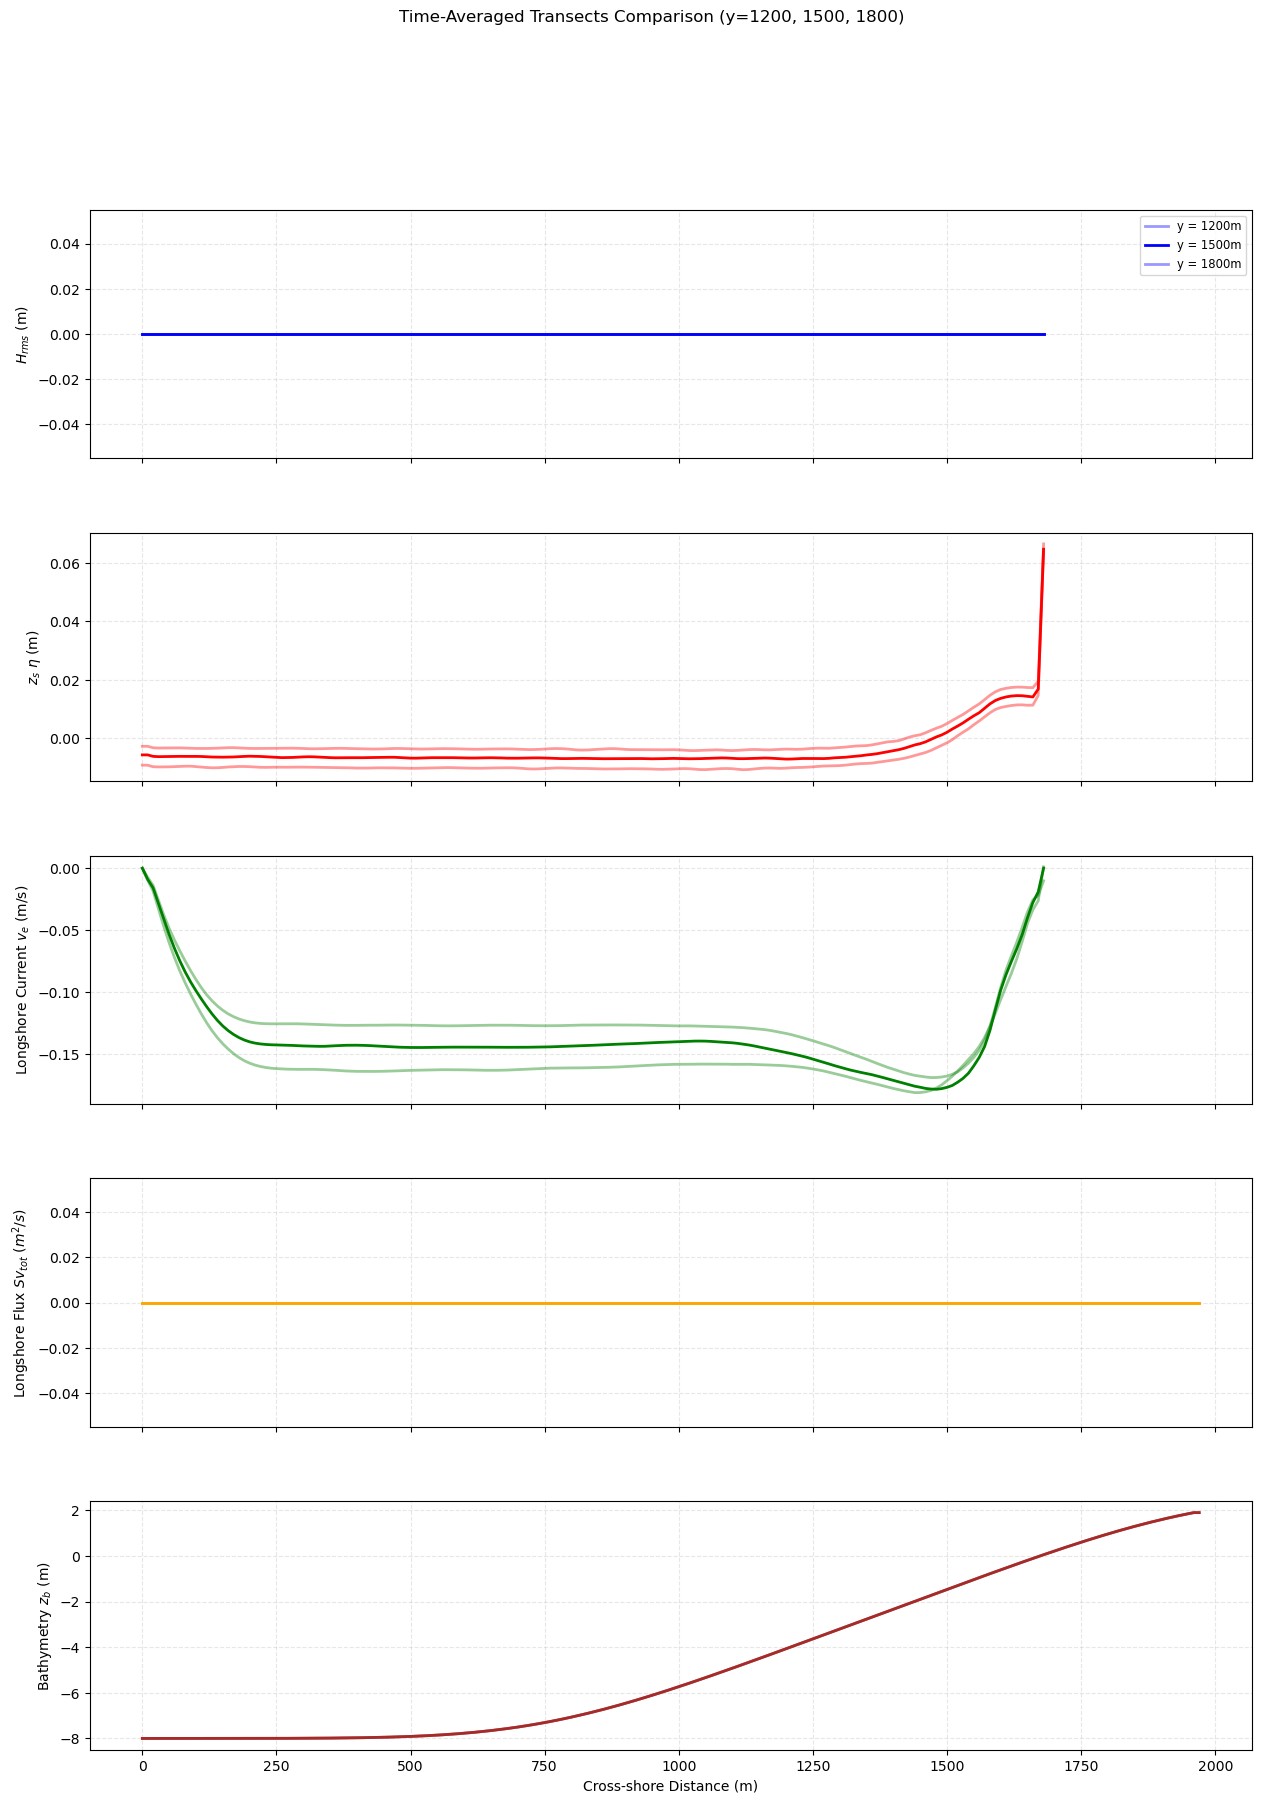

In [49]:
# change y transect values if model space was changed

target_ys = [1200, 1500, 1800]
y_coords_full = ds['globaly'].isel(nx=0).values

vars_to_plot = [
    ('H', '$H_{rms}$ (m)', 'blue'),
    ('zs', '$z_s$ $\eta$ (m)', 'red'),
    ('ve', 'Longshore Current $v_e$ (m/s)', 'green'),
    ('Svtot', 'Longshore Flux $Sv_{tot}$ ($m^2/s$)', 'orange'),
    ('zb', 'Bathymetry $z_b$ (m)', 'brown')
]

n = len(vars_to_plot)

fig, axes = plt.subplots(n, 1, figsize=(15, 4*n), sharex=True)
plt.subplots_adjust(hspace=0.3)

line_styles = ['-', '-', '-']
alphas = [.4, 1.0, .4]

for j, y_target in enumerate(target_ys):
    #find the closest index for specific Y
    ny_idx = np.abs(y_coords_full - y_target).argmin()
    actual_y = y_coords_full[ny_idx]
    x_coords = ds['globalx'].isel(ny=ny_idx).values

    for i, (var_name, label, color) in enumerate(vars_to_plot):
        data_array = ds[var_name].isel(ny=ny_idx).mean(dim='globaltime')
            
        data = data_array.values.squeeze()

        axes[i].plot(x_coords, data, 
                     color=color, 
                     linestyle=line_styles[j], 
                     alpha=alphas[j],
                     linewidth=2, 
                     label=f'y = {actual_y:.0f}m')

        if j == 0:
            axes[i].set_ylabel(label)
            axes[i].grid(True, linestyle='--', alpha=0.3)

axes[0].legend(loc='upper right', fontsize='small')

axes[-1].set_xlabel('Cross-shore Distance (m)')
fig.suptitle('Time-Averaged Transects Comparison (y=1200, 1500, 1800)')

plt.show()